# 2.1. Área bajo restauración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_file = "data"
for file in os.listdir("data"):
    name, ext = os.path.splitext(file)
    if ext == ".csv":
        data_file = f"{data_file}/{file}"

data = pd.read_csv(data_file, header=0)
data

,ID,Restoration program,Institution,Year,Region,ha,Footnote,Source_link
0,1,(+bosques),CONAF-FAO,2025,Maule,2319,Exact date not reported,https://docs.google.com/document/d/18C83Qd9Ibl...
1,2,(+bosques),CONAF-FAO,2025,Ñuble,1247,Exact date not reported,https://docs.google.com/document/d/18C83Qd9Ibl...
2,3,(+bosques),CONAF-FAO,2025,Biobío,2608,Exact date not reported,https://docs.google.com/document/d/18C83Qd9Ibl...
3,4,(+bosques),CONAF-FAO,2025,La Araucanía,2081,Exact date not reported,https://docs.google.com/document/d/18C83Qd9Ibl...
4,5,(+bosques),CONAF-FAO,2025,Los Ríos,3574,Exact date not reported,https://docs.google.com/document/d/18C83Qd9Ibl...
...,...,...,...,...,...,...,...,...
65,66,Siembra_por_Chile,CONAF,2025,La Araucanía,901,NaN,https://docs.google.com/document/d/1eib3RYVeVz...
66,67,Siembra_por_Chile,CONAF,2025,Los Lagos,429,NaN,https://docs.google.com/document/d/1eib3RYVeVz...
67,68,Siembra_por_Chile,CONAF,2025,Los Ríos,441,NaN,https://docs.google.com/document/d/1eib3RYVeVz...
68,69,Siembra_por_Chile,CONAF,2025,Aysén,3775,NaN,https://docs.google.com/document/d/1eib3RYVeVz...


In [3]:
data_region = data.groupby('Region')['ha'].sum().reset_index()
data_region

,Region,ha
0,Antofagasta,261
1,Arica y Parinacota,3068
2,Atacama,158
3,Aysén,19117
4,Biobío,4030
5,Coquimbo,1159
6,La Araucanía,5544
7,Los Lagos,5809
8,Los Ríos,6309
9,Magallanes,1059


In [4]:
list(data_region["Region"])

['Antofagasta',
 'Arica y Parinacota',
 'Atacama',
 'Aysén',
 'Biobío',
 'Coquimbo',
 'La Araucanía',
 'Los Lagos',
 'Los Ríos',
 'Magallanes',
 'Maule',
 'Metropolitana',
 "O'Higgins",
 'Tarapacá',
 'Valparaíso',
 'Ñuble']

In [5]:
region_order = [
    'Arica y Parinacota',
    'Tarapacá',
    'Antofagasta',
    'Atacama',
    'Coquimbo',
    'Valparaíso',
    'Metropolitana',
    "O'Higgins",
    'Maule',
    'Ñuble',
    'Biobío',
    'La Araucanía',
    'Los Ríos',
    'Los Lagos',
    'Aysén',
    'Magallanes',
]

In [6]:
data_region["Region"] = pd.Categorical(data_region["Region"],
                                       categories=region_order,
                                       ordered=True)
data_region.sort_values("Region", inplace=True)
data_region

,Region,ha
1,Arica y Parinacota,3068
13,Tarapacá,291
0,Antofagasta,261
2,Atacama,158
5,Coquimbo,1159
14,Valparaíso,2194
11,Metropolitana,673
12,O'Higgins,5842
10,Maule,5530
15,Ñuble,2658


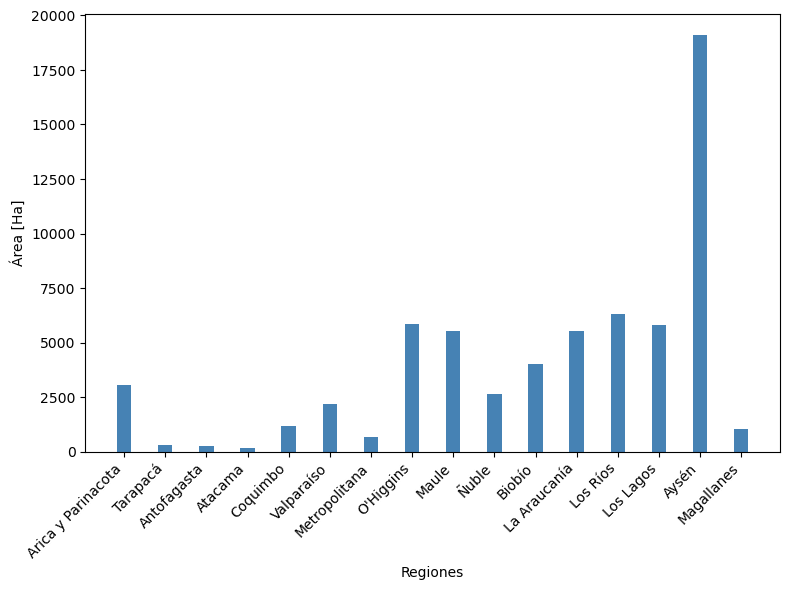

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

position = np.arange(len(data_region))
width = 0.35

ax.bar(position, data_region["ha"], width, label="Área [Ha]", color="steelblue")
ax.set_xlabel("Regiones")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(position)
ax.set_xticklabels(data_region["Region"], rotation=45, ha='right')

fig.savefig("regiones.png")

plt.tight_layout()

In [8]:
data_time = data.groupby('Year')['ha'].sum().reset_index()
data_time['ha (cumulative)'] = data_time['ha'].cumsum()
data_time

,Year,ha,ha (cumulative)
0,2022,11282,11282
1,2023,16237,27519
2,2024,10640,38159
3,2025,25543,63702


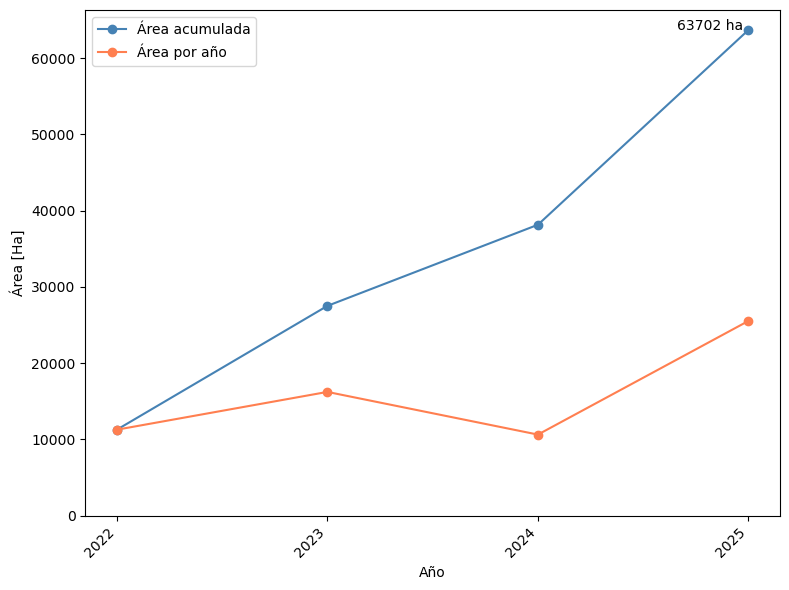

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_time["Year"], data_time["ha (cumulative)"], marker='o', color="steelblue", label="Área acumulada")
ax.text(2025 - 0.34, data_time["ha (cumulative)"][3], f'{data_time["ha (cumulative)"][3]} ha')
ax.set_xlabel("Año")
ax.set_ylabel("Área [Ha]")

ax.set_xticks(data_time["Year"])
ax.set_xticklabels(data_time["Year"], rotation=45, ha='right')
ax.set_ylim(0)

# ax2 = ax.twinx()
ax.plot(data_time["Year"], data_time["ha"], marker='o', color="coral", label="Área por año")
ax.legend()

fig.savefig("years.png")

plt.tight_layout()